In [9]:
# EJECUTA ESTA CELDA PRIMERO
from google.colab import drive
drive.mount('/content/drive')

import sys
# Pon aquí la ruta de Drive donde subiste los archivos .py
ruta_scripts = '/content/drive/MyDrive/PPP/Codigos/'
sys.path.append(ruta_scripts)

print("Rutas configuradas. Ya puedes importar tus módulos.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rutas configuradas. Ya puedes importar tus módulos.


¡Bounding Box encontrado!: (1179, 791, 1789, 1824)


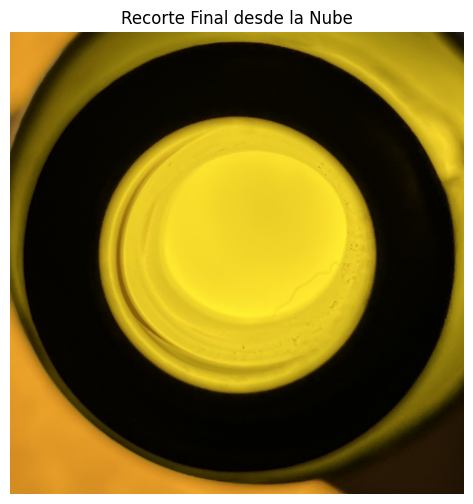

In [28]:
# CELDA 2
import cv2
import matplotlib.pyplot as plt

# Ahora Colab sí sabrá dónde encontrar estos módulos gracias al sys.path
from Centrado import trabajar_con_contorno_blanco
from Cortado import recortar_botella_dinamico

# ⚠️ Modifica esta ruta para apuntar a una imagen defectuosa de tu dataset en Drive
ruta_imagen = '/content/drive/MyDrive/PPP/Dataset/Botellas_Malas/B_M0054.JPG' 

imagen_original = cv2.imread(ruta_imagen)

if imagen_original is not None:
    # 1. Detectar
    bbox = trabajar_con_contorno_blanco(imagen_original, debug=False)
    
    if bbox is not None:
        print(f"¡Bounding Box encontrado!: {bbox}")
        
        # 2. Recortar
        imagen_recortada = recortar_botella_dinamico(imagen_original, bbox, margen=40)
        
        if imagen_recortada is not None:
            # 3. Mostrar
            plt.figure(figsize=(6, 6))
            plt.imshow(cv2.cvtColor(imagen_recortada, cv2.COLOR_BGR2RGB))
            plt.title("Recorte Final desde la Nube")
            plt.axis('off')
            plt.show()
        else:
            print("Error: El recorte falló.")
    else:
        print("No se encontró el contorno de la botella.")
else:
    print("Error cargando la imagen. Revisa la ruta de Drive.")

In [29]:
def procesar_imagen(imagen_recortada, tamano_final = (224,224)):
    if imagen_recortada is None:
        return None
    
    # 1. Convertir a escalas de grises
    imagen_procesada = cv2.cvtColor(imagen_recortada,cv2.COLOR_BGR2GRAY)

    # 2. Filtro Gausseano
    # Un kernel de (5,5) es perfecto para no perder la forma del cuello
    imagen_procesada = cv2.GaussianBlur(imagen_procesada,(5,5),0)

    # 3. Redimensionar la imagen
    imagen_final = cv2.resize(imagen_procesada, tamano_final, interpolation=cv2.INTER_AREA)

    return imagen_final

<function matplotlib.pyplot.show(close=None, block=None)>

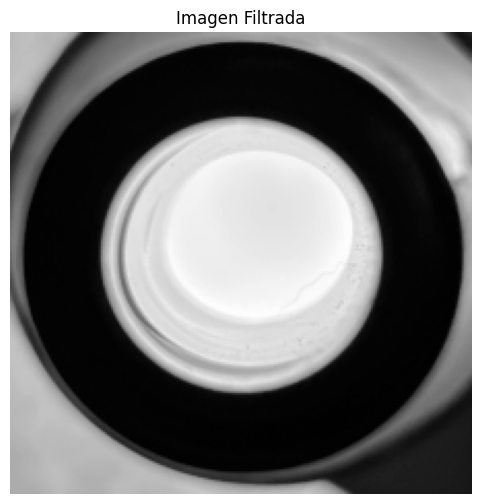

In [30]:
imagen_filtrada = procesar_imagen(imagen_recortada)

# Graficar imagenes
plt.figure(figsize=(6,6))
plt.imshow(imagen_filtrada,cmap = 'gray')
plt.title("Imagen Filtrada")
plt.axis('off')
plt.show